# 5. LayerNorm 层归一化 + RMSNorm：手搓反向传播与可视化（讲课版）

> **minLLM —— 从零实现小型 LLM · 第 5 讲**
>
> 本讲把 LayerNorm 讲透：**纯 NumPy 手搓 forward / backward（逐行中文注释）**，与
> PyTorch `nn.LayerNorm` + autograd 数值对齐（三重验证）；新增 **RMSNorm 变种**
> （MiniMind / LLaMA 实际使用的归一化层，torch 无原生实现，用同公式对比）；
> 用 **matplotlib 可视化**归一化的三步中间过程、LN 输入/输出曲线，以及 LN vs RMSNorm
> 的输出分布差异；最后讲解残差连接与 **Pre-LN / Post-LN** 两种组装方式。
>
> 统一超参：`d_model=8`，`B=2`，`T=4`，`eps=1e-5`（RMSNorm 用 `1e-6`）；
> 随机种子 `np.random.seed(0)` / `torch.manual_seed(0)`，全程 CPU 秒级、完全可复现。


## 一、公式回顾：LayerNorm 定义

对**每个 token** 的特征向量做「标准化 + 仿射」，这就是 LayerNorm：

$$
\text{LayerNorm}(x)=\gamma\odot\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}+\beta,\qquad
\mu=\frac1d\sum_{i=1}^{d}x_i,\qquad
\sigma^2=\frac1d\sum_{i=1}^{d}(x_i-\mu)^2
$$

其中 $x\in\mathbb{R}^d$ 是**一个 token** 的特征向量，$d$ 是特征维度（本讲 $d=8$），
$\gamma,\beta\in\mathbb{R}^d$ 是**可学习**参数，$\epsilon>0$ 是防除零的小常数。

**三个关键点：**

1. **归一到哪个维度？** LayerNorm 对**最后一个维度（特征维）**归一化——每个 token 各自算
   自己的 $\mu,\sigma^2$，token 之间互不影响。BatchNorm 则是对整个 batch 的**同一特征通道**
   求统计量：序列一长一短、batch 一小组统计量就不稳定，所以 Transformer 一律用 LayerNorm。
2. **γ / β 可学习**：归一化把分布压成零均值、单位方差后，仿射 $\gamma\odot\hat{x}+\beta$
   恢复表达能力——初始化 $\gamma=1,\beta=0$ 时等价于恒等变换起步，训练中再慢慢学出合适的尺度。
3. **ε 防除零**：$\sqrt{\sigma^2+\epsilon}$ 保证方差为 0 时也不除零，同时让梯度更稳定。

> 统计口径：$\mu,\sigma^2$ 用的是**总体统计量**（除以 $d$，而非 $d-1$），实现时不做贝塞尔校正。


In [1]:
# ── 0. 导入库 + 统一超参 + 固定种子 ─────────────────────────────────
import numpy as np                # 手搓实现的计算库
import torch                      # torch 参考实现
import torch.nn as nn             # 现成的 nn.LayerNorm 模块
from torch.testing import assert_close   # 数值对比断言（rtol/atol 见对比节）

# 统一超参：小规模，CPU 秒级跑完
d_model = 8          # 特征维（embedding 维度）d
B, T = 2, 4          # batch=2，序列长度 T=4 → 共 B*T = 8 个 token
eps = 1e-5           # LayerNorm 防除零常数 ε

# 固定随机种子：保证每次运行结果完全一致，方便复现与讲课对照
np.random.seed(0); torch.manual_seed(0)

# 构造输入与可学习参数（先用 NumPy；torch 侧稍后拷贝同一份，保证对比同一函数）
x = np.random.randn(B, T, d_model)                # 输入特征 (B, T, d)，近似 N(0,1)
gamma = np.random.uniform(0.5, 1.5, size=d_model) # 缩放参数 γ（初始接近 1）
beta = np.random.uniform(-0.2, 0.2, size=d_model) # 平移参数 β（初始接近 0）
dout = np.random.randn(B, T, d_model)             # 随机"上游梯度"（反向传播对比用）
print(f"输入 x 形状: {x.shape} | 特征维 d={d_model} | 总 token 数 B*T={B*T}")


输入 x 形状: (2, 4, 8) | 特征维 d=8 | 总 token 数 B*T=8


## 二、手搓实现：forward + backward（教学重点）

### 前向：三步走（逐行对照公式）

1. `mu = x.mean(-1, keepdims=True)` —— 沿**最后一个维度**求均值 μ，形状 (…, 1)；
2. `var = ((x - mu) ** 2).mean(-1, keepdims=True)` —— 总体方差 σ²（除 d）；
3. `xhat = (x - mu) / np.sqrt(var + eps)`，`out = gamma * xhat + beta`。

`keepdims=True` 让统计量保持 (…, 1) 形状，与 x 自动**广播**逐元素运算。

### 反向：三条链式路径（关键推导）

先把 batch × 序列的所有 token 贡献在非特征维上求和，得到参数梯度（形状 (d,)）：

$$
d\gamma=\sum_{\text{非特征维}} dout\odot\hat{x},\qquad
d\beta=\sum_{\text{非特征维}} dout
$$

令 $\hat{dx}=dout\odot\gamma$（穿过仿射层），记 $\sigma=\sqrt{var+\epsilon}$。
损失 $L$ 对 $x$ 的依赖有 **3 条链式路径**：

| 路径 | 中间量 | 对 dx 的贡献 |
|---|---|---|
| ① x̂ 直接依赖 x | — | $dx\;+\!\!=\;\hat{dx}/\sigma$ |
| ② var = mean((x−μ)²) 依赖 x | $dvar=\sum_k\hat{dx}_k(x_k-\mu)\cdot(-\tfrac12)(var+\epsilon)^{-\frac32}$ | $dx\;+\!\!=\;dvar\cdot 2(x-\mu)/d$ |
| ③ μ = mean(x) 依赖 x | $d\mu=\sum_k\hat{dx}_k(-1/\sigma)$ | $dx\;+\!\!=\;d\mu/d$ |

其中 μ 路径里还藏着一项「μ 出现在 var 定义中」的链式展开（数值恰为 0，
因 $\sum_i(x_i-\mu)=0$，代码显式保留以展示完整推导）。把三条路径合并并化简，
得到与 PyTorch autograd 等价的**标准形式**：

$$
\frac{\partial L}{\partial x}=\frac{1}{\sigma}\Big(\hat{dx}-\mathrm{mean}(\hat{dx})
-\hat{x}\odot\mathrm{mean}(\hat{dx}\odot\hat{x})\Big),\qquad \hat{dx}=dout\odot\gamma
$$

> **直觉**：第一项沿 x̂ 直传；减去 mean(dx̂) 抵消「μ 随 x 移动」的依赖；再减去
> x̂⊙mean(dx̂⊙x̂) 抵消「σ 随 x 变化」的依赖——归一化的反向，就像在梯度上做了一次
> **中心化 + 去相关**。后面 RMSNorm 的反向就是这一式去掉「−mean(dx̂)」。


In [2]:
# ── 1. 手搓 LayerNorm：forward + backward（纯 NumPy，逐行中文注释）──

def layernorm_forward(x, gamma, beta, eps=1e-5):
    """LayerNorm 前向：对每个 token 的特征维做 归一化 + 仿射。
    x 的最后一维是特征维（如 (B,T,d)）；gamma/beta 形状 (d,)；返回与 x 同形状。
    """
    # 第 1 步：沿最后一个维度（特征维）求均值 μ；keepdims 保留形状 (…, 1) 便于广播
    mu = x.mean(-1, keepdims=True)
    # 第 2 步：总体方差 σ² = mean((x - μ)²)；除以 d（不做贝塞尔校正）
    var = ((x - mu) ** 2).mean(-1, keepdims=True)
    # 第 3 步：标准化 x̂ = (x - μ) / √(σ² + ε)：减去均值、除以标准差
    xhat = (x - mu) / np.sqrt(var + eps)
    # 仿射：out = γ ⊙ x̂ + β，恢复表达能力（γ=1, β=0 时为恒等变换）
    out = gamma * xhat + beta
    return out

def layernorm_backward(dout, x, gamma, eps=1e-5):
    """LayerNorm 反向：返回 (dx, dgamma, dbeta)。
    链式展开（三条路径）等价于 autograd 标准形式：
    dx = (1/σ)·(dxhat − mean(dxhat) − x̂·mean(dxhat⊙x̂))，其中 dxhat = dout⊙γ。
    """
    d = x.shape[-1]                    # 特征维大小 d（∂μ/∂x_i = 1/d 会用到）
    # 前向过程重算一遍（教学版显式重算；工程上可缓存进 cache 避免重复计算）
    mu = x.mean(-1, keepdims=True)
    var = ((x - mu) ** 2).mean(-1, keepdims=True)
    xhat = (x - mu) / np.sqrt(var + eps)
    sigma = np.sqrt(var + eps)         # 预计算 σ，避免后面反复开根号

    # ── 参数梯度：B×T 个 token 的贡献在非特征维上求和 → 形状 (d,) ──
    dgamma = np.sum(dout * xhat, axis=tuple(range(dout.ndim - 1)))  # dγ = Σ dout⊙x̂
    dbeta = np.sum(dout, axis=tuple(range(dout.ndim - 1)))          # dβ = Σ dout
    # ── 输入梯度 dx：合并三条链式路径 ──
    dxhat = dout * gamma               # 先穿过仿射层：dx̂ = dout⊙γ
    # 路径②（经 var）：dvar = Σ_k dxhat_k·(x_k−μ) · (−½)·(var+ε)^(−3/2)
    dvar = np.sum(dxhat * (x - mu), axis=-1, keepdims=True) * (-0.5) * (var + eps) ** (-1.5)
    # 路径③（经 μ）：第一项来自 x̂ 中的 (x−μ)；第二项来自"μ 出现在 var 定义里"的
    #               链式展开（数值恰为 0：Σ(x−μ)=0，保留以展示完整推导）
    dmu = (
        np.sum(dxhat * (-1.0 / sigma), axis=-1, keepdims=True)
        + dvar * (-2.0 / d) * np.sum(x - mu, axis=-1, keepdims=True)
    )
    # 合并：① x̂ 直传 dxhat/σ；② var 路径 dvar·2(x−μ)/d；③ μ 路径 dmu/d（∂μ/∂x_i=1/d）
    dx = dxhat / sigma + dvar * 2.0 * (x - mu) / d + dmu / d
    return dx, dgamma, dbeta


## 三、PyTorch 参考实现

用 `nn.LayerNorm(d_model, eps=eps)` 作为参考层，并把它的 `weight` / `bias`
**拷贝成与手搓完全相同的 γ / β**——保证对比的是同一个函数（同输入、同参数、同 ε）。

`x_t` 开启 `requires_grad=True`，执行 `out_t.backward(gradient=dout_t)`，
让 autograd 一次性产出三类梯度：

| 梯度 | autograd 位置 | 含义 |
|---|---|---|
| `dx_t` | `x_t.grad` | 输入梯度 ∂L/∂x，形状 (B, T, d) |
| `dgamma_t` | `ln.weight.grad` | γ 的梯度，形状 (d,) |
| `dbeta_t` | `ln.bias.grad` | β 的梯度，形状 (d,) |

> 手搓 backward 与 autograd 是**两条完全独立的推导**：一个用链式法则逐路径合并，
> 一个用计算图自动求导——两边对齐，说明推导无误。


In [3]:
# ── 2. PyTorch 参考：nn.LayerNorm + autograd ──────────────────────

ln = nn.LayerNorm(d_model, eps=eps)   # 参考层：对最后一维做 LayerNorm
with torch.no_grad():                 # 拷贝同一份 γ/β，保证与手搓是同一个函数
    ln.weight.copy_(torch.tensor(gamma, dtype=torch.float32))
    ln.bias.copy_(torch.tensor(beta, dtype=torch.float32))

x_t = torch.tensor(x, dtype=torch.float32, requires_grad=True)   # 输入（要梯度）
dout_t = torch.tensor(dout, dtype=torch.float32)                 # 上游梯度

out_t = ln(x_t)                             # 前向
out_t.backward(gradient=dout_t)             # 自动求导：一次产出三类梯度
dx_t = x_t.grad                             # autograd 的 dx，形状 (B,T,d)
dgamma_t = ln.weight.grad                   # autograd 的 dγ，形状 (d,)
dbeta_t = ln.bias.grad                      # autograd 的 dβ，形状 (d,)


## 四、数值对比：手搓 vs PyTorch autograd（三重验证）

逐项对比并用 `assert_close(rtol=1e-4, atol=1e-6)` 断言，打印最大绝对误差：

| 对比项 | 含义 | 形状 |
|---|---|---|
| forward `out` | 前向输出 | (B, T, d) |
| `dx` | 输入梯度（dout 反传） | (B, T, d) |
| `dγ` / `dβ` | 参数梯度 | (d,) |

三重验证：

1. **手搓 vs autograd**：forward / dx / dγ / dβ 逐项对比；
2. **标准形式等价**：手搓"链式展开版" dx 应与教材标准形式
   $(1/\sigma)(\hat{dx}-\mathrm{mean}(\hat{dx})-\hat{x}\odot\mathrm{mean}(\hat{dx}\odot\hat{x}))$
   逐位一致（误差应 ≈ 0）；
3. **有限差分自检**：以 $L=\sum dout\odot\text{LN}(x)$ 为标量损失，用中心差分
   $\dfrac{\partial L}{\partial x_i}\approx\dfrac{L(x+he_i)-L(x-he_i)}{2h}$ 抽查一个元素，
   给手搓解析反向做第三重独立校验。


In [4]:
# ── 3. 数值对比：forward / dx / dγ / dβ + 标准形式等价 + 有限差分 ──

def to_t(a):
    """numpy 数组 → float32 tensor（与 autograd 产物 dtype 一致，避免断言失败）"""
    return torch.tensor(a, dtype=torch.float32)

# 1) 前向输出对比：手搓 vs nn.LayerNorm（同一份 γ/β）
out_np = layernorm_forward(x, gamma, beta, eps)
err_fwd = float(np.abs(out_np - out_t.detach().numpy()).max())
assert_close(to_t(out_np), out_t, rtol=1e-4, atol=1e-6)
print(f"forward  max abs err = {err_fwd:.3e}")

# 2) 反向梯度对比：dx / dγ / dβ（手搓 backward vs autograd）
dx, dgamma, dbeta = layernorm_backward(dout, x, gamma, eps)
err_dx = float(np.abs(dx - dx_t.numpy()).max())
err_dg = float(np.abs(dgamma - dgamma_t.numpy()).max())
err_db = float(np.abs(dbeta - dbeta_t.numpy()).max())
assert_close(to_t(dx), dx_t, rtol=1e-4, atol=1e-6)
assert_close(to_t(dgamma), dgamma_t, rtol=1e-4, atol=1e-6)
assert_close(to_t(dbeta), dbeta_t, rtol=1e-4, atol=1e-6)
print(f"dx      max abs err = {err_dx:.3e}")
print(f"dgamma  max abs err = {err_dg:.3e}")
print(f"dbeta   max abs err = {err_db:.3e}")
# 3) 标准形式等价自检：链式展开版 dx 应等于教材标准形式（误差 ≈ 0）
dxhat = dout * gamma
mu_c = x.mean(-1, keepdims=True)
var_c = ((x - mu_c) ** 2).mean(-1, keepdims=True)
sigma_c = np.sqrt(var_c + eps)
xhat_c = (x - mu_c) / sigma_c
dx_std = (dxhat - dxhat.mean(-1, keepdims=True)
          - xhat_c * (dxhat * xhat_c).mean(-1, keepdims=True)) / sigma_c
err_std = float(np.abs(dx_std - dx).max())
print(f"标准形式 vs 链式展开 dx 最大误差 = {err_std:.3e}（应 ≈ 0）")
# 4) 有限差分独立校验 dx：中心差分抽查一个元素
def loss_fn(xx):
    """标量损失 L = Σ dout ⊙ LN(xx)，供中心差分使用"""
    return float(np.sum(dout * layernorm_forward(xx, gamma, beta, eps)))

idx = (0, 0, 3)                # 抽查 (batch0, token0, 特征3)
h = 1e-6
xp = x.copy(); xp[idx] += h
xn = x.copy(); xn[idx] -= h
grad_num = (loss_fn(xp) - loss_fn(xn)) / (2 * h)   # 中心差分近似 ∂L/∂x
grad_ana = dx[idx]
print(f"有限差分 dx{idx}: 数值 {grad_num:.8f} | 解析 {grad_ana:.8f} | 误差 {abs(grad_num - grad_ana):.2e}")

# 5) 最终判定：全部对比通过才打印 ✓ PASS
max_err = max(err_fwd, err_dx, err_dg, err_db, err_std)
print("✓ PASS" if max_err < 1e-4 else "✗ FAIL", f"(max abs err = {max_err:.3e})")


forward  max abs err = 3.404e-07
dx      max abs err = 2.959e-07
dgamma  max abs err = 4.708e-07
dbeta   max abs err = 3.785e-07
标准形式 vs 链式展开 dx 最大误差 = 4.996e-16（应 ≈ 0）
有限差分 dx(0, 0, 3): 数值 -1.10601430 | 解析 -1.10601430 | 误差 5.54e-10
✓ PASS (max abs err = 4.708e-07)


## 五、中间过程可视化：归一化到底在做什么？

LayerNorm 对**每个 token** 依次做两件事：**减去自己的均值 μ**（中心化）→
**除以自己的标准差 σ**（缩放）。本节用图把三步中间态画出来：

- **图 1（3 个子图）**：用全体 8 个 token 的 64 个特征值做直方图，对照
  ① 原始 x → ② 减去各自 μ 后 → ③ 再除以各自 σ 后（逼近标准正态 N(0,1)，叠加参考曲线）；
- **图 2（曲线）**：解剖单个 token (0,0)（即 B=0 的样本），画出 8 个原始特征值与
  LN 输出值，标注该 token 的 μ（红色虚线）与 μ±σ 区间（红色阴影）的位置，
  直观看到"归一化 + 仿射"的组合效果。


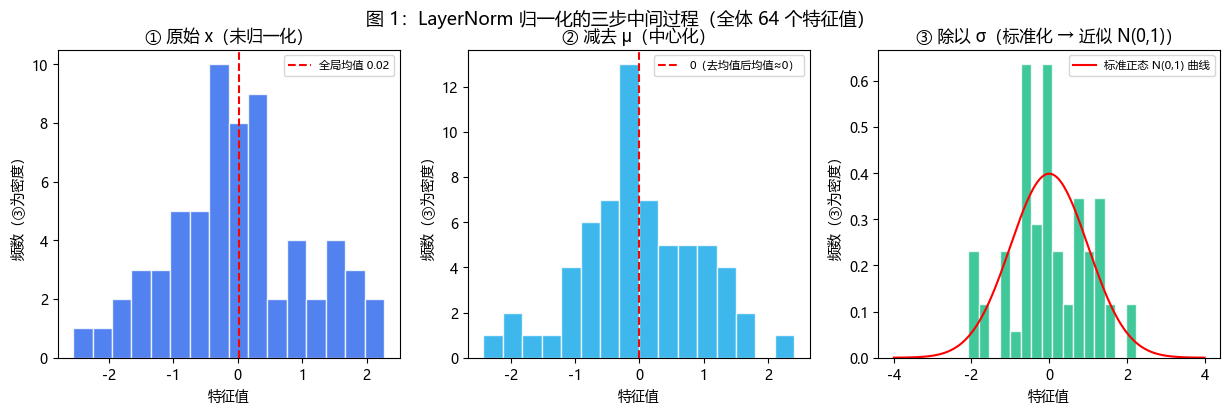

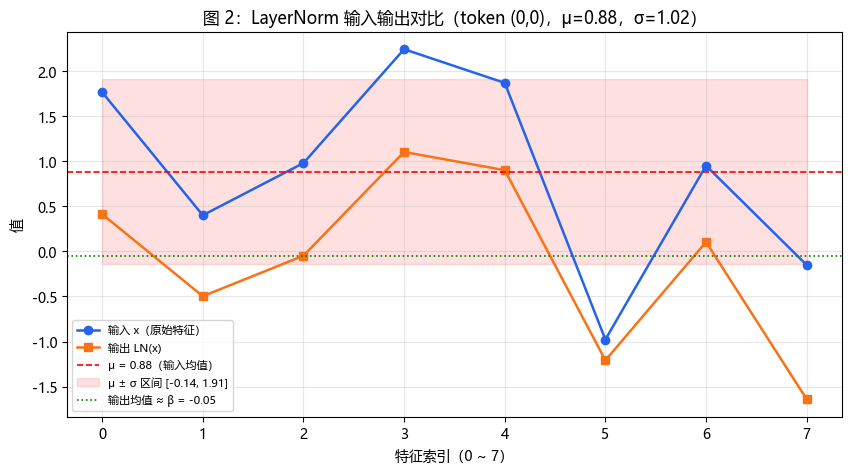

示例 token (0,0)：μ=0.8841，σ=1.0227；去均值后均值≈-5.55e-17，标准化后均值≈-8.33e-17，方差≈1.0000


In [5]:
# ── 4. 中间过程可视化（matplotlib）────────────────────────────────
import matplotlib; matplotlib.use('Agg')   # 无显示环境兜底：先设非交互后端
# 切到 inline 后端：show() 的图才会被捕获进 notebook（行魔法须单独一行）
%matplotlib inline
import matplotlib.pyplot as plt
# 中文字体设置（本机无中文字体时回退默认，仅影响显示，不影响运行）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False   # 让坐标轴负号正常显示

# 准备全体 token 数据（B*T=8 个 token 的 64 个特征值）与每 token 的统计量
all_x = x.reshape(-1)                          # 全体原始特征值
mu_all = x.mean(-1, keepdims=True)             # 每个 token 自己的 μ
var_all = ((x - mu_all) ** 2).mean(-1, keepdims=True)   # 每个 token 自己的 σ²
centered_all = (x - mu_all).reshape(-1)        # 中间态 1：去均值后的全体值
std_all = ((x - mu_all) / np.sqrt(var_all + eps)).reshape(-1)  # 中间态 2：标准化后的全体值
# ── 图 1：归一化三步中间过程（3 个子图）─────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4))
# ① 原始 x：总体方差=1，但每个 token 内部围绕各自的均值散布
axes1[0].hist(all_x, bins=16, color='#2563EB', alpha=0.8, edgecolor='white')
axes1[0].axvline(all_x.mean(), color='red', ls='--', lw=1.5,
                 label=f'全局均值 {all_x.mean():.2f}')
axes1[0].set_title('① 原始 x（未归一化）')
# ② 减去各自 μ：全体值集中到 0 附近，均值被抹平
axes1[1].hist(centered_all, bins=16, color='#0EA5E9', alpha=0.8, edgecolor='white')
axes1[1].axvline(0, color='red', ls='--', lw=1.5, label='0（去均值后均值≈0）')
axes1[1].set_title('② 减去 μ（中心化）')
# ③ 再除以各自 σ：方差被压到 1，逼近标准正态
axes1[2].hist(std_all, bins=16, color='#10B981', alpha=0.8, edgecolor='white', density=True)
xx = np.linspace(-4, 4, 200)
axes1[2].plot(xx, np.exp(-xx ** 2 / 2) / np.sqrt(2 * np.pi), 'r-', lw=1.5,
              label='标准正态 N(0,1) 曲线')
axes1[2].set_title('③ 除以 σ（标准化 → 近似 N(0,1)）')
for ax in axes1:
    ax.set_xlabel('特征值'); ax.set_ylabel('频数（③为密度）'); ax.legend(fontsize=8)
fig1.suptitle('图 1：LayerNorm 归一化的三步中间过程（全体 64 个特征值）', fontsize=13)
plt.show()
# ── 图 2：单个 token 的输入 / 输出曲线对比（标注 μ 与 ±σ 的位置）──
x0 = x[0, 0]                                     # 解剖样本：token (0,0) 的 8 个特征值
mu0 = x0.mean()                                  # 该 token 的 μ
sigma0 = np.sqrt(((x0 - mu0) ** 2).mean() + eps) # 该 token 的 σ = √(σ²+ε)
out0 = layernorm_forward(x0, gamma, beta, eps)   # 该 token 的 LN 输出（8 维）
feat = np.arange(d_model)                        # 特征索引 0..7

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(feat, x0, 'o-', color='#2563EB', lw=1.8, label='输入 x（原始特征）')
ax2.plot(feat, out0, 's-', color='#F97316', lw=1.8, label='输出 LN(x)')
ax2.axhline(mu0, color='red', ls='--', lw=1.2, label=f'μ = {mu0:.2f}（输入均值）')
ax2.fill_between(feat, mu0 - sigma0, mu0 + sigma0, color='red', alpha=0.12,
                 label=f'μ ± σ 区间 [{mu0 - sigma0:.2f}, {mu0 + sigma0:.2f}]')
ax2.axhline(beta.mean(), color='green', ls=':', lw=1.2,
            label=f'输出均值 ≈ β = {beta.mean():.2f}')
ax2.set_xlabel('特征索引（0 ~ 7）'); ax2.set_ylabel('值')
ax2.set_title(f'图 2：LayerNorm 输入输出对比（token (0,0)，μ={mu0:.2f}，σ={sigma0:.2f}）')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.show()

# 附：把该 token 的三步中间态数值也打印出来，对照图 1 的结论
x0_centered = x0 - mu0                           # 中间态 1：去均值
x0_std = x0_centered / sigma0                    # 中间态 2：标准化
print(f"示例 token (0,0)：μ={mu0:.4f}，σ={sigma0:.4f}；"
      f"去均值后均值≈{x0_centered.mean():.2e}，标准化后均值≈{x0_std.mean():.2e}，方差≈{x0_std.var():.4f}")


## 六、RMSNorm 变种：MiniMind / LLaMA 实际使用的归一化层

LayerNorm 要算均值再算方差（两趟 mean）；RMSNorm 只保留**方差部分**——等价于
**只做缩放、不做中心化**：

$$
\text{RMSNorm}(x)=\gamma\odot\frac{x}{\sqrt{\mathrm{mean}(x^2)+\epsilon}},\qquad
\text{RMS}(x)=\sqrt{\mathrm{mean}(x^2)+\epsilon}
$$

**与 LayerNorm 的三个区别：**

1. **无均值中心化**：不计算 μ、不减去 μ。Zhang & Sennrich (2019) 观察到
   LayerNorm 的"减去均值"对 Transformer 收益很小，去掉后效果几乎不变；
2. **无可学习 β**：只有 γ 一个可学习参数，参数与计算都省一半；
3. **反传更简单**：RMSNorm 输入梯度
   $dx=\big(\hat{dx}-\hat{x}\odot\mathrm{mean}(\hat{dx}\odot\hat{x})\big)/r$
   比 LN 少一项 $-\mathrm{mean}(\hat{dx})$（LN 要额外抵消均值中心化的依赖）。

**为什么效果相当？** LLM 的激活**均值本来就接近 0**（初始化与残差连接的累积效应），
中心化带来的收益有限；真正需要稳定的是**幅度/方差**（防止数值爆炸、保持各层尺度一致）。
所以在精度几乎不变的前提下，RMSNorm 以更低算力成为 LLaMA、MiniMind 等现代 LLM 的默认选择。

> 工程细节：LLaMA / MiniMind 使用 `eps=1e-6`；实现上常用
> `x * torch.rsqrt(mean(x²) + eps)` 一次到位（rsqrt = 平方根倒数）。
> torch 没有原生 RMSNorm 模块，本讲用**同公式的 torch 实现** + autograd 做数值对比。


RMSNorm forward max abs err = 2.504e-07
RMSNorm dx      max abs err = 2.542e-07
RMSNorm dgamma  max abs err = 3.751e-07
✓ PASS RMSNorm 手搓 vs torch (max abs err = 3.751e-07)


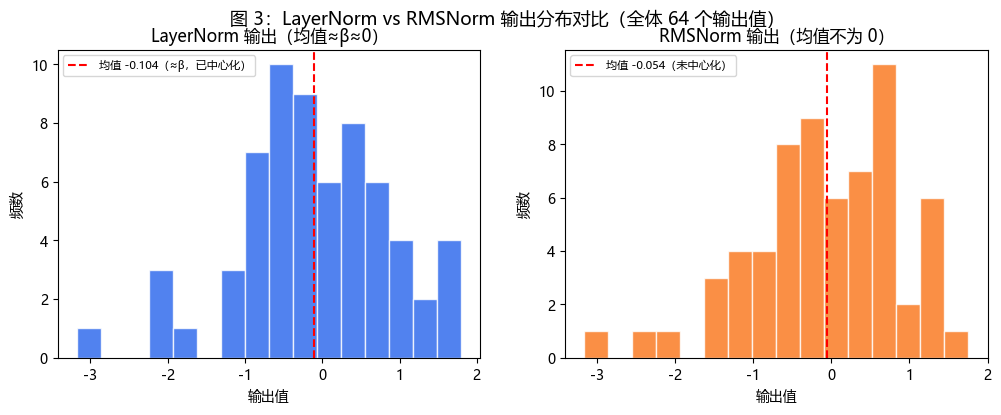

LN 输出均值 ≈ -0.1038（≈β 均值）| RMSNorm 输出均值 ≈ -0.0536（未中心化）


In [6]:
# ── 5. RMSNorm 手搓（forward + backward）+ torch 同公式对比 + 可视化 ──

def rmsnorm_forward(x, gamma, eps=1e-6):
    """RMSNorm 前向：只做缩放、不做均值中心化（没有 β）。
    out = γ ⊙ x / √(mean(x²) + ε)；x 最后一维为特征维，gamma 形状 (d,)。
    """
    r = np.sqrt((x ** 2).mean(-1, keepdims=True) + eps)   # RMS 归一化因子 r
    xhat = x / r                                          # 标准化：x̂ = x / r
    out = gamma * xhat                                    # 仿射：只有 γ，没有 β
    return out

def rmsnorm_backward(dout, x, gamma, eps=1e-6):
    """RMSNorm 反向：返回 (dx, dgamma)。
    dx = (dxhat − x̂·mean(dxhat⊙x̂)) / r，其中 dxhat = dout⊙γ，r = √(mean(x²)+ε)；
    相比 LN 的 dx 恰好少了 "−mean(dxhat)" 一项（LN 要抵消均值中心化依赖）。
    """
    r = np.sqrt((x ** 2).mean(-1, keepdims=True) + eps)   # 重新计算 r（教学版显式重算）
    xhat = x / r
    # 参数梯度：非特征维上求和 → 形状 (d,)（只有 γ，没有 β）
    dgamma = np.sum(dout * xhat, axis=tuple(range(dout.ndim - 1)))
    # 输入梯度：标准形式一条表达式（无需展开 r 的链式，化简见 docstring）
    dxhat = dout * gamma
    dx = (dxhat - xhat * (dxhat * xhat).mean(-1, keepdims=True)) / r
    return dx, dgamma
# torch 参考：torch 无原生 RMSNorm，用同公式实现，让 autograd 产出梯度
def rmsnorm_torch(x_t, gamma_t, eps=1e-6):
    """PyTorch 版 RMSNorm：与手搓完全同公式，仅换成 tensor 运算"""
    r = torch.sqrt((x_t ** 2).mean(-1, keepdim=True) + eps)
    return gamma_t * x_t / r

eps_rms = 1e-6                                     # RMSNorm 的 ε（LLaMA / MiniMind 取值）
out_rms = rmsnorm_forward(x, gamma, eps_rms)       # 手搓前向

# torch 侧：x 与 γ 都要梯度（x 是输入，γ 是参数）
x_rt = torch.tensor(x, dtype=torch.float32, requires_grad=True)
gamma_rt = torch.tensor(gamma, dtype=torch.float32, requires_grad=True)
out_rt = rmsnorm_torch(x_rt, gamma_rt, eps_rms)
out_rt.backward(torch.tensor(dout, dtype=torch.float32))   # autograd 反传
dx_rms, dgamma_rms = rmsnorm_backward(dout, x, gamma, eps_rms)

# 数值对比：forward / dx / dγ
err_fwd_r = float(np.abs(out_rms - out_rt.detach().numpy()).max())
err_dx_r = float(np.abs(dx_rms - x_rt.grad.numpy()).max())
err_dg_r = float(np.abs(dgamma_rms - gamma_rt.grad.numpy()).max())
assert_close(torch.tensor(out_rms, dtype=torch.float32), out_rt.detach(), rtol=1e-4, atol=1e-6)
assert_close(torch.tensor(dx_rms, dtype=torch.float32), x_rt.grad, rtol=1e-4, atol=1e-6)
assert_close(torch.tensor(dgamma_rms, dtype=torch.float32), gamma_rt.grad, rtol=1e-4, atol=1e-6)
max_err_r = max(err_fwd_r, err_dx_r, err_dg_r)
print(f"RMSNorm forward max abs err = {err_fwd_r:.3e}")
print(f"RMSNorm dx      max abs err = {err_dx_r:.3e}")
print(f"RMSNorm dgamma  max abs err = {err_dg_r:.3e}")
print("✓ PASS RMSNorm 手搓 vs torch" if max_err_r < 1e-4 else "✗ FAIL RMSNorm",
      f"(max abs err = {max_err_r:.3e})")
# ── 可视化：LN vs RMSNorm 输出直方图对比（2 个子图）─────────────
import matplotlib; matplotlib.use('Agg')   # 无显示环境兜底（上一 cell 已是 inline，这里再兜一次）
# 切到 inline 后端：show() 的图才会被捕获进 notebook（行魔法须单独一行）
%matplotlib inline
ln_all = layernorm_forward(x, gamma, beta, eps).reshape(-1)   # 全体 token 的 LN 输出
rms_all = out_rms.reshape(-1)                                 # 全体 token 的 RMSNorm 输出

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4))
axes3[0].hist(ln_all, bins=16, color='#2563EB', alpha=0.8, edgecolor='white')
axes3[0].axvline(ln_all.mean(), color='red', ls='--', lw=1.5,
                 label=f'均值 {ln_all.mean():.3f}（≈β，已中心化）')
axes3[0].set_title('LayerNorm 输出（均值≈β≈0）')
axes3[1].hist(rms_all, bins=16, color='#F97316', alpha=0.8, edgecolor='white')
axes3[1].axvline(rms_all.mean(), color='red', ls='--', lw=1.5,
                 label=f'均值 {rms_all.mean():.3f}（未中心化）')
axes3[1].set_title('RMSNorm 输出（均值不为 0）')
for ax in axes3:
    ax.set_xlabel('输出值'); ax.set_ylabel('频数'); ax.legend(fontsize=8)
fig3.suptitle('图 3：LayerNorm vs RMSNorm 输出分布对比（全体 64 个输出值）', fontsize=13)
plt.show()

print(f"LN 输出均值 ≈ {ln_all.mean():.4f}（≈β 均值）| RMSNorm 输出均值 ≈ {rms_all.mean():.4f}（未中心化）")


## 七、残差连接与 Pre-LN / Post-LN

**残差连接**（Residual Connection）是 Transformer 的另一块基石：

$$
y = x + \text{Sublayer}(x)
$$

两个好处：

1. **梯度经恒等旁路直传**：$\partial y/\partial x$ 中恒含单位阵 $I$，把深度网络的
   梯度路径"短路"，缓解梯度消失——深层也能训起来；
2. **学习增量**：网络只需在 $x$ 之上学习一个"增量"，优化更简单。

归一化层与残差有两种组装方式：

| 结构 | 公式 | 特点 |
|---|---|---|
| **Post-LN**（原始 Transformer 论文） | $h=\text{LN}\big(x+\text{Sub}(x)\big)$ | 表达力强；但残差旁路的梯度还要再过 LN 的 $\div\sigma$ 缩放，深层梯度易被压小，需要 warmup 等技巧 |
| **Pre-LN**（现代主流） | $h=x+\text{Sub}\big(\text{LN}(x)\big)$ | 恒等旁路完全不经过 LN，梯度以单位阵直传，训练稳、通常免 warmup（GPT 等现代模型默认） |

> **现代 LLM 用 Pre-LN 的根本原因**：深层网络中，Post-LN 的残差旁路梯度会被 LN 的
> $1/\sigma$ 缩放不断压小，导致深层难训练、需要 warmup；Pre-LN 把 LN 挪到子层**前面**，
> 恒等路径上没有任何归一化运算，梯度直接以单位矩阵回传——训练更稳。


In [7]:
# ── 6. 残差连接 + Pre-LN / Post-LN 演示 ──────────────────────────

def simple_sublayer(xx, W, b):
    """简版子层（仅示意）：线性变换 + ReLU，代表注意力 / FFN 这类子层"""
    return np.maximum(xx @ W + b, 0.0)

W = np.random.randn(d_model, d_model) * 0.1   # 子层权重（随机即可，仅演示用）
b = np.zeros(d_model)                         # 子层偏置
# 1) 最朴素的残差连接：y = x + Sublayer(x)，恒等旁路直接相加
y_res = x + simple_sublayer(x, W, b)
print("残差连接输出形状:", y_res.shape, "（与输入 x 一致）")

# 2) Post-LN（原始论文）：先加残差，再归一化
x_post = layernorm_forward(x + simple_sublayer(x, W, b), gamma, beta, eps)

# 3) Pre-LN（现代主流）：先归一化，再过子层，再加残差
x_pre = x + simple_sublayer(layernorm_forward(x, gamma, beta, eps), W, b)

print("Post-LN 输出形状:", x_post.shape)
print("Pre-LN  输出形状:", x_pre.shape)
print("Post-LN 例值:", np.round(x_post[0, 0, :3], 4),
      "| Pre-LN 例值:", np.round(x_pre[0, 0, :3], 4))


残差连接输出形状: (2, 4, 8) （与输入 x 一致）
Post-LN 输出形状: (2, 4, 8)
Pre-LN  输出形状: (2, 4, 8)
Post-LN 例值: [ 0.5138 -0.2715 -0.0068] | Pre-LN 例值: [1.9451 0.6643 0.9787]


## 八、总结

- **归一化在做什么**：把每个 token 的特征分布稳定到「由可学习 γ/β 控制的尺度」，
  消除层间激活的均值 / 方差漂移，缓解梯度消失 / 爆炸——这是深层 Transformer 能稳定训练的前提。
- **LN vs RMSNorm 取舍**：LN 多做一步均值中心化、多一个 β，统计量更完整；RMSNorm 去掉
  中心化与 β（省算力、少参数），在 LLM 激活均值≈0 的现实里效果几乎不变，反传还少一项
  `−mean(dxhat)`——所以 LLaMA / MiniMind 用 RMSNorm（`eps=1e-6`）。会推导 LN，RMSNorm 顺带就会。
- **残差 + 归一化**：残差提供梯度直通旁路，归一化稳定分布，两者以 Pre-LN 组装是
  现代 LLM 的默认结构（免 warmup、深层训练稳）。
- **minLLM 对应位置**：本讲是 `transformer_from_scratch` 系列的「地基」——手搓的
  LayerNorm forward/backward 与 RMSNorm 反传推导，正是 minLLM 每个 Transformer Block 中
  「RMSNorm + 多头注意力 + FFN + 残差（Pre-LN）」的第一步；下一讲将把这些积木拼成完整 Block。
